#  Bank Customer Churn — Binary Classification
## Exploratory Data Analysis

**Kaggle Competition** | [Playground Series S4E1](https://www.kaggle.com/competitions/playground-series-s4e1)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.data_loader import load_data, train_path, test_path

train = load_data(train_path)
test = load_data(test_path)

print("Train Shape : ", train.shape)
print("Test Shape : ", test.shape)
train.head(5)

Train Shape :  (165034, 14)
Test Shape :  (110023, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


---
## 1. Dataset Overview

In [3]:
print("Columns types: ")
print(train.dtypes.to_string())
print()
train.describe()

Columns types: 
id                   int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64



,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [4]:
NUM_COLS = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
CAT_COLS = ["Geography", "Gender"]
BIN_COLS = ["HasCrCard", "IsActiveMember"]

---
## 2. Target Variable — Class Imbalance

In [5]:
def class_balance(y: pd.Series) -> None:
    counts = y.value_counts()
    pct = y.value_counts(normalize=True) * 100
    print(f"Class balance:\n  0 (stayed)  : {counts[0]:>6,}  ({pct[0]:.1f}%)")
    print(f"  1 (churned) : {counts[1]:>6,}  ({pct[1]:.1f}%)")
    print(f"  Imbalance ratio : {counts[0]/counts[1]:.1f}:1")

Class balance:
  0 (stayed)  : 130,113  (78.8%)
  1 (churned) : 34,921  (21.2%)
  Imbalance ratio : 3.7:1


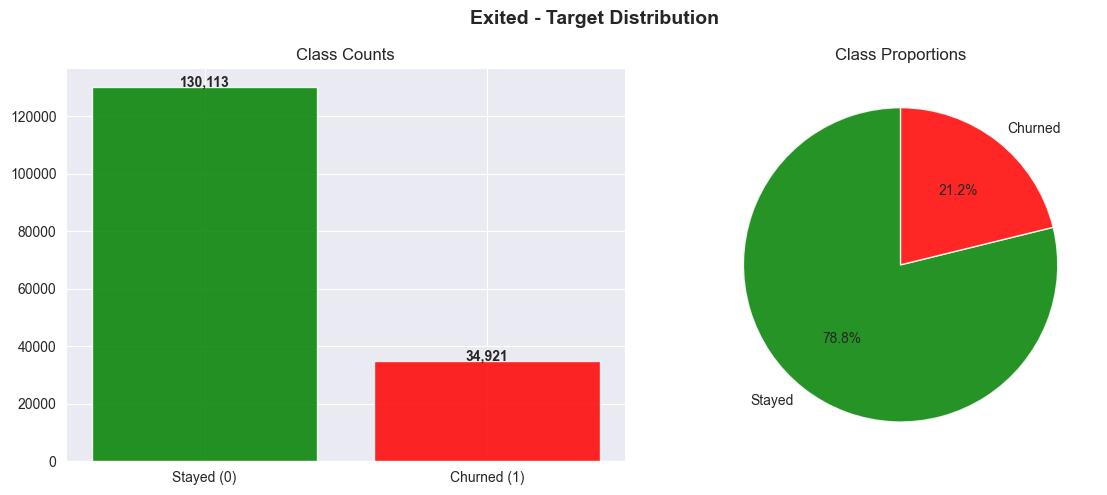

In [6]:
y = train['Exited']
class_balance(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Exited - Target Distribution", fontsize=14, fontweight="bold")

counts = y.value_counts()
axes[0].bar(["Stayed (0)", "Churned (1)"], counts.values,
            color=["g", "r"], alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Class Counts")

axes[1].pie(counts.values, labels=["Stayed", "Churned"],
            autopct="%1.1f%%", colors=["g", "r"],
            startangle=90, wedgeprops={"alpha": 0.85})
axes[1].set_title("Class Proportions")

plt.tight_layout()

**Class imbalance (~20% churn)** requires:
- `StratifiedKFold` during cross-validation to preserve the ratio in each fold
- `scale_pos_weight` (XGBoost/LightGBM) tuned via Optuna
- `class_weight='balanced'` for Random Forest
- ROC-AUC as the evaluation metric (invariant to class imbalance, unlike accuracy)

---
## 3. Missing Values

In [7]:
def missing_summary(df: pd.DataFrame, label: str = "Dataset") -> pd.DataFrame:
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    miss_pct = (miss / len(df) * 100).round(2)
    return pd.DataFrame(
        {"Missing": miss, "Missing (%)": miss_pct}
    ).rename_axis(f"{label} — Column")

In [8]:
train_miss = missing_summary(train, 'Train')
test_miss  = missing_summary(test,  'Test')
print(f'Train missing: {len(train_miss)} columns')
print(f'Test  missing: {len(test_miss)} columns')
if len(train_miss) > 0:
    display(train_miss)
else:
    print('No missing values in train set ✓')

Train missing: 0 columns
Test  missing: 0 columns
No missing values in train set ✓


---
## 4. Numerical Features Analysis

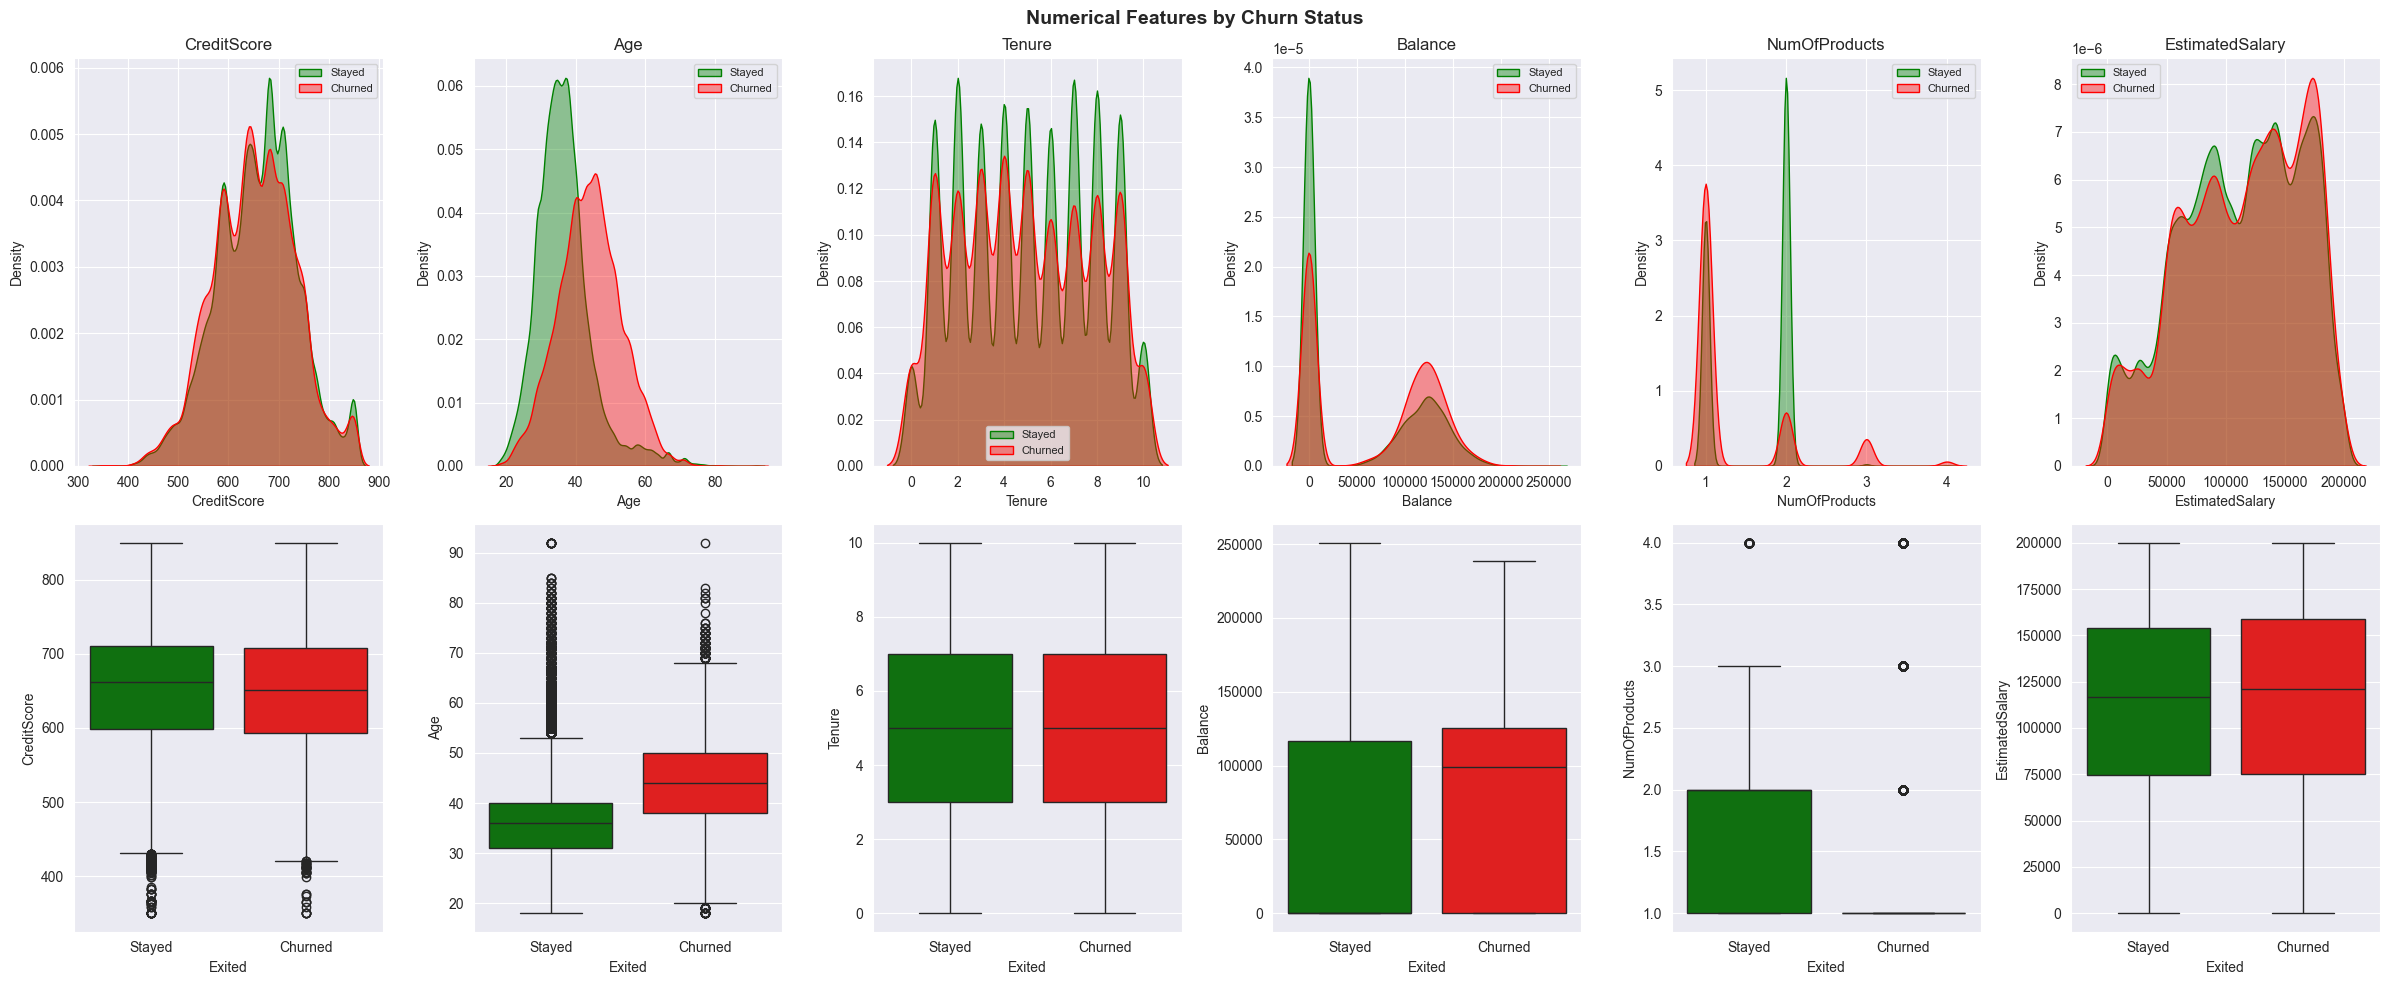

In [9]:
fig, axes = plt.subplots(2, len(NUM_COLS), figsize=(len(NUM_COLS)*4, 10))
fig.suptitle("Numerical Features by Churn Status", fontsize=14, fontweight="bold")

for i, col in enumerate(NUM_COLS):
    for val, color, label in [(0, "g", "Stayed"), (1, "r", "Churned")]:
        sns.kdeplot(
            data=train[train["Exited"]==val][col],
            ax=axes[0,i],
            fill=True,
            alpha=0.4,
            color=color,
            label=label)

    axes[0, i].set_title(col)
    axes[0, i].legend(fontsize=8)

    sns.boxplot(
        data=train,
        x="Exited",
        y=col,
        ax=axes[1,i],
        palette={0: "g", 1: "r"},
        hue="Exited",
        legend=False)
    axes[1, i].set_xticks([0, 1])
    axes[1, i].set_xticklabels(["Stayed", "Churned"])

plt.tight_layout()

---
## 5. Categorical & Binary Features

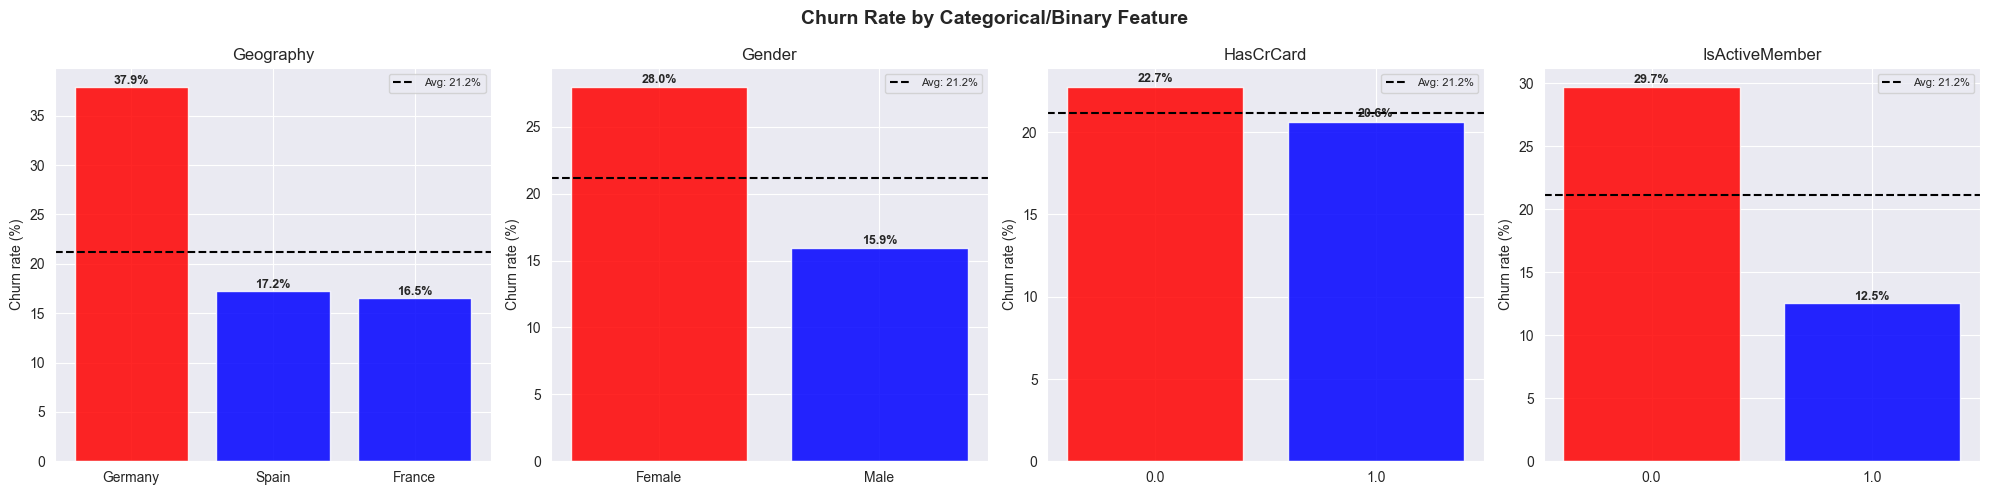

In [10]:
all_cat = CAT_COLS + BIN_COLS
fig, axes = plt.subplots(1, len(all_cat), figsize=(len(all_cat)*5, 5))
fig.suptitle("Churn Rate by Categorical/Binary Feature", fontsize=14, fontweight="bold")

overall_rate = train["Exited"].mean()

for ax, col in zip(axes, all_cat):
    churn_rate = train.groupby(col)["Exited"].mean().sort_values(ascending=False)
    colors = ["r" if v > overall_rate else "b" for v in churn_rate.values]
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values * 100,
                  color=colors, alpha=0.85)
    ax.axhline(overall_rate * 100, color="black", linestyle="--",
               linewidth=1.5, label=f"Avg: {overall_rate*100:.1f}%")
    ax.set_title(col)
    ax.set_ylabel("Churn rate (%)")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val*100:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()

---
## 6. Feature Engineering Insights

In [11]:
df = train.copy()

safe_salary = df["EstimatedSalary"].replace(0, np.nan)
safe_prods  = df["NumOfProducts"].replace(0, np.nan)

df["BalanceToSalary"]   = df["Balance"] / safe_salary
df["CreditScorePerAge"] = df["CreditScore"] / df["Age"]
df["BalancePerProduct"] = df["Balance"] / safe_prods
df["BalanceIsZero"] = (df["Balance"] == 0).astype(int)
df["IsNew"] = (df["Tenure"] <= 1).astype(int)
df["IsLoyal"] = (df["Tenure"] >= 8).astype(int)
df["EngagementScore"] = df["NumOfProducts"] + df["IsActiveMember"] + df["HasCrCard"]
df["InactiveRich"] = ((df["IsActiveMember"]==0) & (df["Balance"] > df["Balance"].median())).astype(int)
df["Age_x_NumProducts"] = df["Age"] * df["NumOfProducts"]

eng_cols = ["BalanceToSalary",
            "CreditScorePerAge",
            "BalancePerProduct",
            "BalanceIsZero",
            "IsNew",
            "IsLoyal",
            "EngagementScore",
            "InactiveRich",
            "Age_x_NumProducts"]

print("Churn rate — engineered features (top splits):")
results = []
for col in eng_cols:
    if df[col].nunique() <= 3:
        for val in sorted(df[col].unique()):
            rate = df[df[col]==val]["Exited"].mean()
            results.append({"Feature": f"{col}={val}", "Churn Rate": rate,
                            "Count": (df[col]==val).sum()})
    else:
        corr = df[col].corr(df["Exited"])
        results.append({"Feature": col, "Churn Rate (corr)": corr, "Count": df[col].notna().sum()})

pd.DataFrame(results).fillna("").head(20)

Churn rate — engineered features (top splits):


,Feature,Churn Rate (corr),Count,Churn Rate
0,BalanceToSalary,0.001559,165034,
1,CreditScorePerAge,-0.287183,165034,
2,BalancePerProduct,0.141889,165034,
3,BalanceIsZero=0,,75386,0.270992
4,BalanceIsZero=1,,89648,0.161654
5,IsNew=0,,143267,0.208387
6,IsNew=1,,21767,0.232738
7,IsLoyal=0,,124896,0.213394
8,IsLoyal=1,,40138,0.206014
9,EngagementScore,-0.26792,165034,


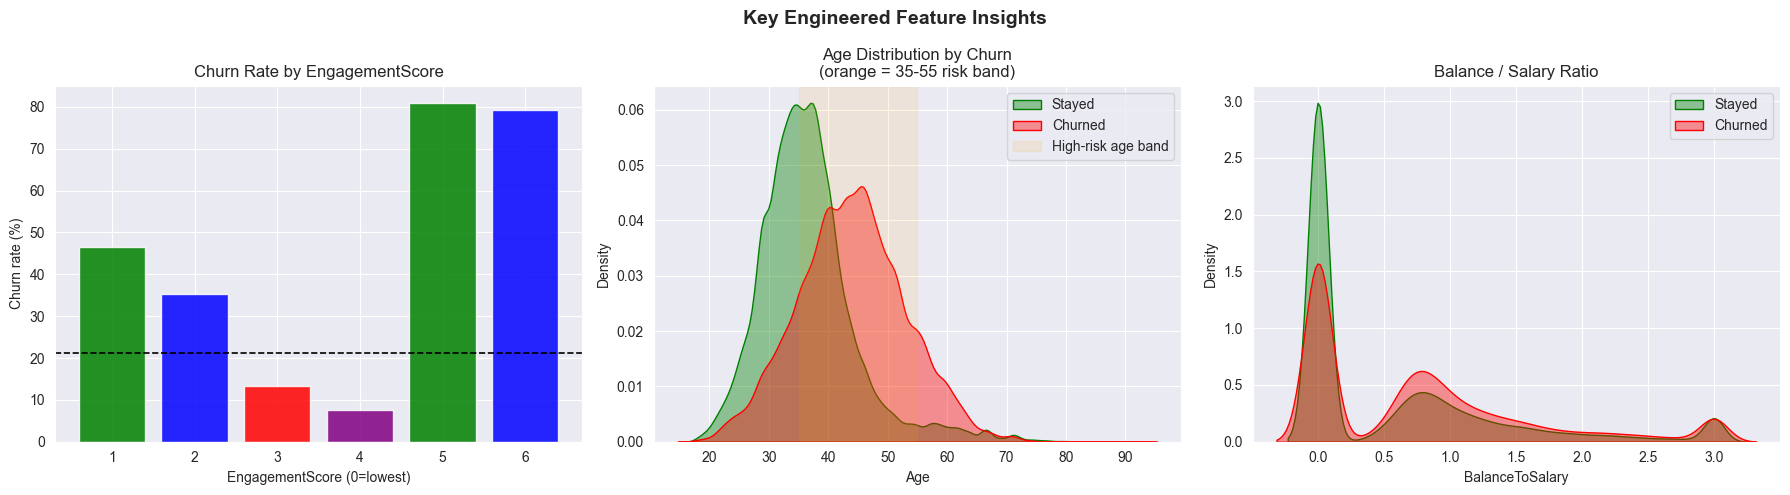

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Key Engineered Feature Insights", fontsize=14, fontweight="bold")

eng_churn = df.groupby("EngagementScore")["Exited"].mean()
axes[0].bar(eng_churn.index, eng_churn.values * 100, color=["g", "b", "r", "purple"][:len(eng_churn)], alpha=0.85)
axes[0].axhline(overall_rate * 100, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Churn Rate by EngagementScore")
axes[0].set_xlabel("EngagementScore (0=lowest)")
axes[0].set_ylabel("Churn rate (%)")

sns.kdeplot(df[df["Exited"]==0]["Age"], ax=axes[1], fill=True, alpha=0.4, color="g", label="Stayed")
sns.kdeplot(df[df["Exited"]==1]["Age"], ax=axes[1], fill=True, alpha=0.4, color="r", label="Churned")
axes[1].axvspan(35, 55, alpha=0.1, color="orange", label="High-risk age band")
axes[1].legend()
axes[1].set_title("Age Distribution by Churn\n(orange = 35-55 risk band)")

bts_churned = df[df["Exited"]==1]["BalanceToSalary"].clip(0, 3)
bts_stayed  = df[df["Exited"]==0]["BalanceToSalary"].clip(0, 3)
sns.kdeplot(bts_stayed,  ax=axes[2], fill=True, alpha=0.4, color="g", label="Stayed")
sns.kdeplot(bts_churned, ax=axes[2], fill=True, alpha=0.4, color="r", label="Churned")
axes[2].set_title("Balance / Salary Ratio")
axes[2].legend()

plt.tight_layout()

---
## 7. Segment-Level Rolling Statistics

In [13]:
geo_stats = train.groupby("Geography").agg(
    CreditScore_median=("CreditScore", "median"),
    CreditScore_std=("CreditScore", "std"),
    Balance_median=("Balance", "median"),
    Churn_rate=("Exited", "mean"),
    Count=("Exited", "count")
).round(2)

print("Segment stats by Geography:")
display(geo_stats)

prod_stats = train.groupby("NumOfProducts").agg(
    Age_median=("Age", "median"),
    Churn_rate=("Exited", "mean"),
    Count=("Exited", "count")
).round(2)

print("\nSegment stats by NumOfProducts:")
display(prod_stats)

Segment stats by Geography:


,CreditScore_median,CreditScore_std,Balance_median,Churn_rate,Count
Geography,,,,,
France,660.0,79.44,0.00,0.17,94215
Germany,657.0,80.96,122028.65,0.38,34606
Spain,660.0,80.98,0.00,0.17,36213



Segment stats by NumOfProducts:


,Age_median,Churn_rate,Count
NumOfProducts,,,
1,38.0,0.35,77374
2,36.0,0.06,84291
3,43.0,0.88,2894
4,44.0,0.88,475


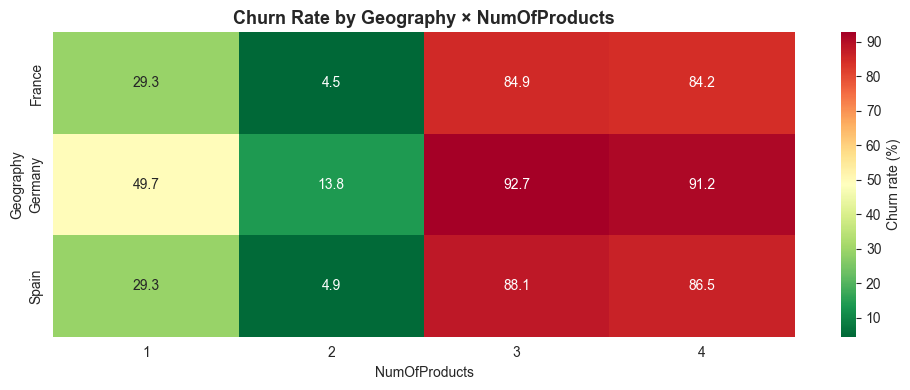

In [14]:
pivot = train.pivot_table(values="Exited", index="Geography",
                           columns="NumOfProducts", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot * 100, annot=True, fmt=".1f", cmap="RdYlGn_r",
            ax=ax, cbar_kws={"label": "Churn rate (%)"})
ax.set_title("Churn Rate by Geography × NumOfProducts", fontsize=13, fontweight="bold")
plt.tight_layout()

**Key finding:** Germany has ~2× higher churn rate than France/Spain across all product categories. The `SegmentStatsTransformer` captures this peer-group context per customer — the tabular equivalent of rolling-window statistics.

---
## 8. Correlation Analysis

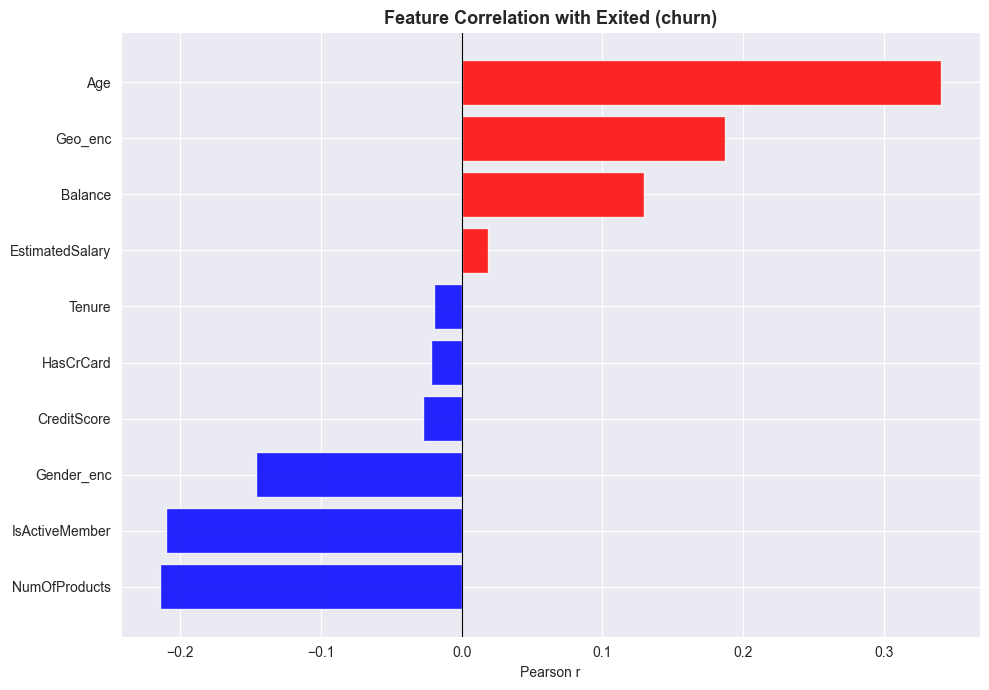

In [15]:
df_enc = train.copy()
df_enc["Gender_enc"] = (df_enc["Gender"] == "Male").astype(int)
df_enc["Geo_enc"] = df_enc["Geography"].map({"France": 0, "Spain": 1, "Germany": 2})
df_enc = df_enc.drop(columns=["Geography", "Gender", "id", "CustomerId", "Surname"])

corr_target = df_enc.corr()["Exited"].drop("Exited").sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["r" if v > 0 else "b" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Exited (churn)", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson r")
plt.tight_layout()

---
## 9. Skewness & Log-Transform Justification

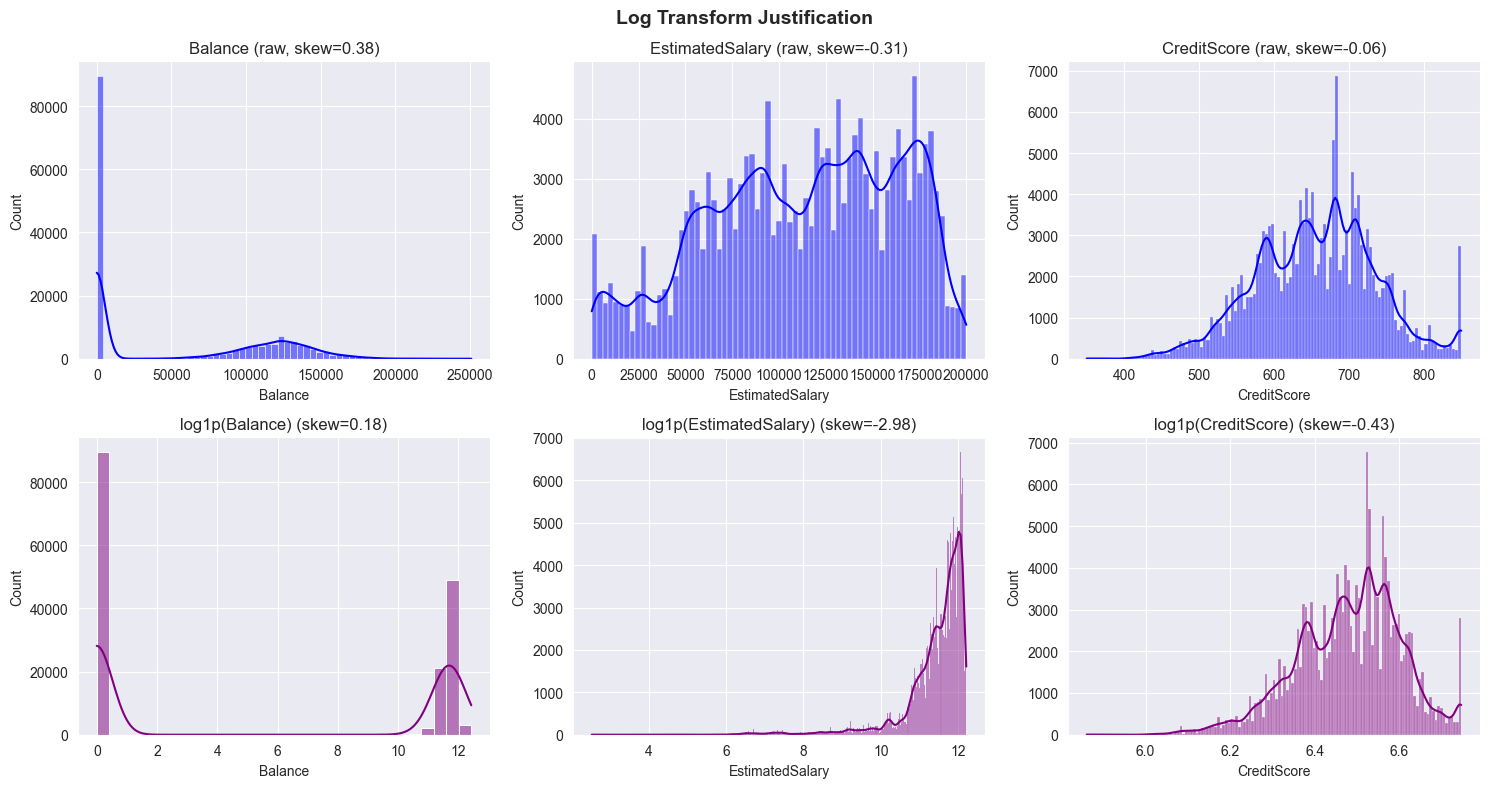

In [16]:
log_features = ["Balance", "EstimatedSalary", "CreditScore"]

fig, axes = plt.subplots(2, len(log_features), figsize=(len(log_features)*5, 8))
fig.suptitle("Log Transform Justification", fontsize=14, fontweight="bold")

for i, col in enumerate(log_features):
    raw  = train[col].clip(lower=0)
    logt = np.log1p(raw)

    sns.histplot(raw,  kde=True, ax=axes[0, i], color="b")
    axes[0, i].set_title(f"{col} (raw, skew={raw.skew():.2f})")

    sns.histplot(logt, kde=True, ax=axes[1, i], color="purple")
    axes[1, i].set_title(f"log1p({col}) (skew={logt.skew():.2f})")

plt.tight_layout()